In [1]:
import importlib
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from conformal_predictions import fsc_score
from pyldl.utils import load_dataset, LDLEarlyStopping, LossHistory
from pyldl.algorithms import BEDL_LDL, SNEFY_LDL

np.random.seed(0)
keras.utils.set_random_seed(0)

## Load SBU_3DFE and split into train / calibration / test

Calibration must be disjoint from the training set for split conformal prediction to give valid coverage.

In [2]:
X, D = load_dataset('Yeast_spo5', dir='dataset')
print(f'Yeast_spo5: {X.shape[0]} samples, {X.shape[1]} features, {D.shape[1]} labels')

X_trainval, X_test, D_trainval, D_test = train_test_split(
    X, D, test_size=0.2, random_state=0)
X_train, X_cal, D_train, D_cal = train_test_split(
    X_trainval, D_trainval, test_size=0.25, random_state=0)

print(f'train: {X_train.shape[0]}  cal: {X_cal.shape[0]}  test: {X_test.shape[0]}')

Yeast_spo5: 2465 samples, 24 features, 3 labels
train: 1479  cal: 493  test: 493


## Train BEDL_LDL with the `bayes_mse` loss

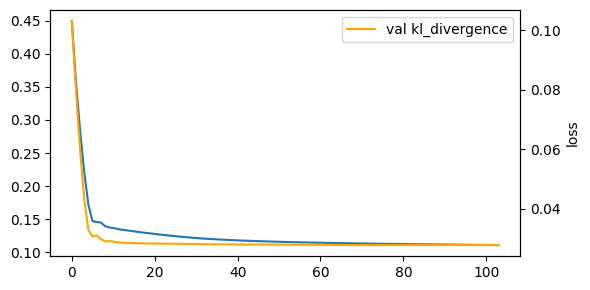

In [3]:
model = BEDL_LDL(n_hidden=32)

loss_history = LossHistory()
early_stop = LDLEarlyStopping(monitor='kl_divergence', patience=20, minimum=20)

model.fit(
    X_train, D_train,
    loss_type='bayes_mse',
    X_val=X_cal, D_val=D_cal,
    epochs=500,
    batch_size=256,
    callbacks=[early_stop, loss_history],
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
)

plt.figure(figsize=(6, 3))
plt.plot(loss_history.history['loss'], label='train loss')
ax2 = plt.twinx()
ax2.plot(loss_history.history['kl_divergence'], label='val kl_divergence', color='orange')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.tight_layout(); plt.show()

In [87]:
noise_X = np.random.uniform(low=X_train.min(), high=X_train.max(), size=X_test.shape)
noise_D = np.random.uniform(low=D_train.min(), high=D_train.max(), size=D_test.shape)

print(noise_X.shape, noise_D.shape)

(493, 24) (493, 3)


## Run split conformal prediction

In [4]:
CONFIDENCE = 0.9
BIN_COUNT  = 8

result = fsc_score(
    model,
    X_cal, D_cal,
    X_test, D_test,
    confidence=CONFIDENCE,
    bin_count=BIN_COUNT,
)

print(f'target marginal coverage : {CONFIDENCE:.2f}')
print(f'q_hat (per label)        : {np.round(result["q_hat"], 4)}')
print(f'per-label FSC            : {np.round(result["per_label_fsc"], 4)}')
print(f'mean per-label FSC       : {result["per_label_fsc"].mean():.4f}')
print(f'joint FSC (all labels)   : {result["joint_fsc"]:.4f}')
print(f'worst-bin FSC            : {result["worst_bin_fsc"]:.4f}')

target marginal coverage : 0.90
q_hat (per label)        : [3.1152 5.772  7.4167]
per-label FSC            : [0.8661 0.8945 0.8966]
mean per-label FSC       : 0.8857
joint FSC (all labels)   : 0.7688
worst-bin FSC            : 0.7903


In [5]:
# worst bin per label
for i in range(result['per_label_fsc'].shape[0]):
    worst_bin_idx = np.argmin(result['per_bin_fsc'][i])
    print(f'label {i} worst bin idx: {worst_bin_idx}, FSC: {result["per_bin_fsc"][i, worst_bin_idx]:.4f}')

label 0 worst bin idx: 6, FSC: 0.7903
label 1 worst bin idx: 6, FSC: 0.8065
label 2 worst bin idx: 0, FSC: 0.8226


## Visualize coverage

Per-label coverage rate vs. the target, and the per-(label, bin) coverage heatmap. NaN bins (empty) are masked.

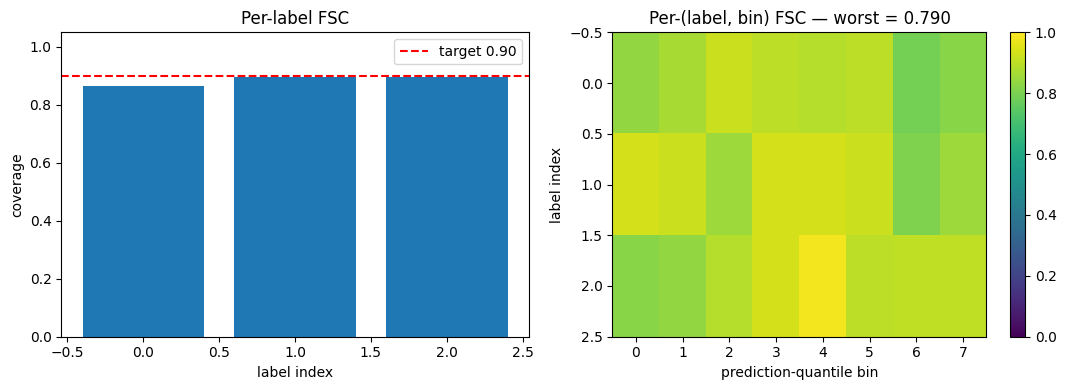

In [6]:
K = D_test.shape[1]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(np.arange(K), result['per_label_fsc'])
axes[0].axhline(CONFIDENCE, color='red', linestyle='--', label=f'target {CONFIDENCE:.2f}')
axes[0].set_xlabel('label index'); axes[0].set_ylabel('coverage')
axes[0].set_title('Per-label FSC'); axes[0].set_ylim(0, 1.05); axes[0].legend()

im = axes[1].imshow(result['per_bin_fsc'], aspect='auto', vmin=0, vmax=1, cmap='viridis')
axes[1].set_xlabel('prediction-quantile bin'); axes[1].set_ylabel('label index')
axes[1].set_title(f'Per-(label, bin) FSC — worst = {result["worst_bin_fsc"]:.3f}')
fig.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

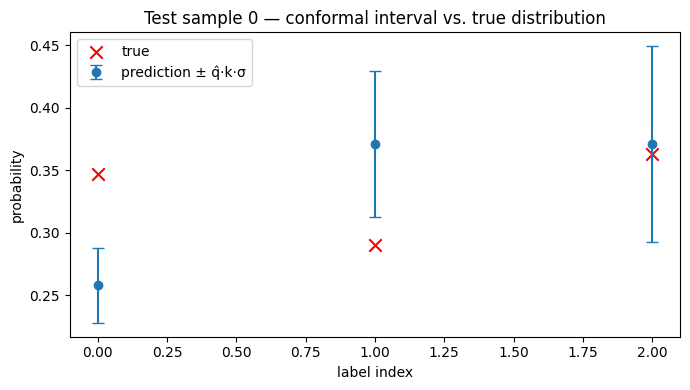

In [108]:
sample_idx = 0
labels = np.arange(K)
plt.figure(figsize=(7, 4))
plt.errorbar(
    labels, result['D_pred_test'][sample_idx],
    yerr=[result['D_pred_test'][sample_idx] - result['lower'][sample_idx],
          result['upper'][sample_idx] - result['D_pred_test'][sample_idx]],
    fmt='o', capsize=4, label='prediction ± q̂·k·σ',
)
plt.scatter(labels, D_test[sample_idx], color='red', marker='x', s=80, label='true')
plt.xlabel('label index'); plt.ylabel('probability')
plt.title(f'Test sample {sample_idx} — conformal interval vs. true distribution')
plt.legend(); plt.tight_layout(); plt.show()

In [102]:
Dbar

array([0.33217629, 0.3255781 , 0.34224562])

In [104]:
Dvar

array([95.46118265, 33.7949204 , 19.51389919])

In [103]:
alpha

array([31.70994104, 11.00288589,  6.67854647])

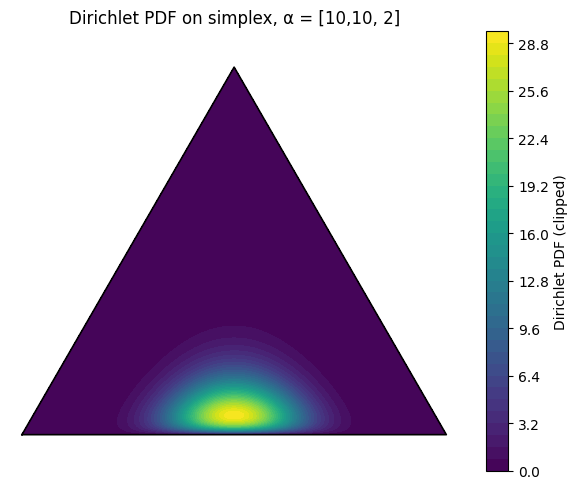

In [9]:
from math import lgamma

Dbar = np.mean(D_train, axis=0)
Dvar = np.mean(Dbar*(1 - Dbar)/(np.var(D_train, axis=0) + 1e-8) - 1)

# Dirichlet(0.3, 0.3, 0.4) PDF on the 2-simplex
alpha = np.array([10, 10, 2])  # Dbar*Dvar

# Build a dense triangular grid of barycentric coordinates (x1, x2, x3), x1+x2+x3=1
n = 180
bary = []
for i in range(n + 1):
    for j in range(n + 1 - i):
        k = n - i - j
        bary.append([i / n, j / n, k / n])
bary = np.array(bary)

# Avoid exact zeros (alpha < 1 gives boundary singularities)
eps = 1e-6
x = np.clip(bary, eps, 1 - eps)

# log Dirichlet pdf = sum((a_i-1)log x_i) - log B(alpha)
log_B = np.sum([lgamma(a) for a in alpha]) - lgamma(np.sum(alpha))
log_pdf = np.sum((alpha - 1.0) * np.log(x), axis=1) - log_B
pdf = np.exp(log_pdf)

# Map simplex to 2D triangle for plotting
# Vertices: e1->(0,0), e2->(1,0), e3->(0.5, sqrt(3)/2)
xy = np.column_stack([
    bary[:, 1] + 0.5 * bary[:, 2],
    (np.sqrt(3) / 2.0) * bary[:, 2]
])

# Clip extreme spikes so the interior is visible
vmax = np.percentile(pdf, 99.9999)

tri = plt.matplotlib.tri.Triangulation(xy[:, 0], xy[:, 1])
plt.figure(figsize=(6, 5))
cntr = plt.tricontourf(tri, np.clip(pdf, 0, vmax), levels=40, cmap="viridis")
plt.colorbar(cntr, label="Dirichlet PDF (clipped)")
plt.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], "k-", lw=1.2)

plt.title("Dirichlet PDF on simplex, α = " + np.array2string(alpha, precision=2, separator=','))
plt.axis("equal")
plt.axis("off")
plt.tight_layout()
plt.show()

Mean D_train: [0.33217629 0.3255781  0.34224562]


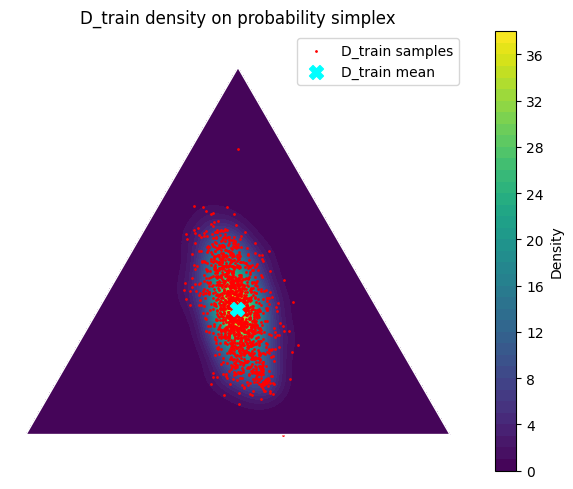

In [100]:
# Heat map of D_train on the 2-simplex (K=3)
assert D_train.shape[1] == 3, "Simplex plot requires exactly 3 labels."
D_bar = np.mean(D_train, axis=0)
print(f"Mean D_train: {D_bar}")
# Map barycentric coords (p1,p2,p3) to 2D triangle:
# e1 -> (0,0), e2 -> (1,0), e3 -> (0.5, sqrt(3)/2)
xy_train = np.column_stack([
    D_train[:, 1] + 0.5 * D_train[:, 2],
    (np.sqrt(3) / 2.0) * D_train[:, 2]
])

# Dense triangular grid on the simplex
n_grid = 120
simplex_bary = []
for i in range(n_grid + 1):
    for j in range(n_grid + 1 - i):
        simplex_bary.append([i / n_grid, j / n_grid, (n_grid - i - j) / n_grid])
simplex_bary = np.array(simplex_bary)

xy_grid = np.column_stack([
    simplex_bary[:, 1] + 0.5 * simplex_bary[:, 2],
    (np.sqrt(3) / 2.0) * simplex_bary[:, 2]
])

# Simple Gaussian KDE on the simplex grid
h = 0.03
diff = xy_grid[:, None, :] - xy_train[None, :, :]
dist2 = np.sum(diff**2, axis=2)
density = np.exp(-0.5 * dist2 / (h * h)).sum(axis=1) / (xy_train.shape[0] * 2 * np.pi * h * h)

# Plot heat map
tri_grid = plt.matplotlib.tri.Triangulation(xy_grid[:, 0], xy_grid[:, 1])
plt.figure(figsize=(6, 5))
cont = plt.tricontourf(tri_grid, density, levels=40, cmap="viridis")
plt.colorbar(cont, label="Density")
plt.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], "w-", lw=1.2)
plt.scatter(xy_train[:, 0], xy_train[:, 1], c="red", s=1, label="D_train samples")
plt.scatter(D_bar[1] + 0.5 * D_bar[2], (np.sqrt(3) / 2.0) * D_bar[2], c="cyan", s=100, marker="X", label="D_train mean")
plt.legend()


plt.title("D_train density on probability simplex")
plt.axis("equal")
plt.axis("off")
plt.tight_layout()
plt.show()

Fitted Dirichlet alpha: [11.2259 11.0029 11.5662]


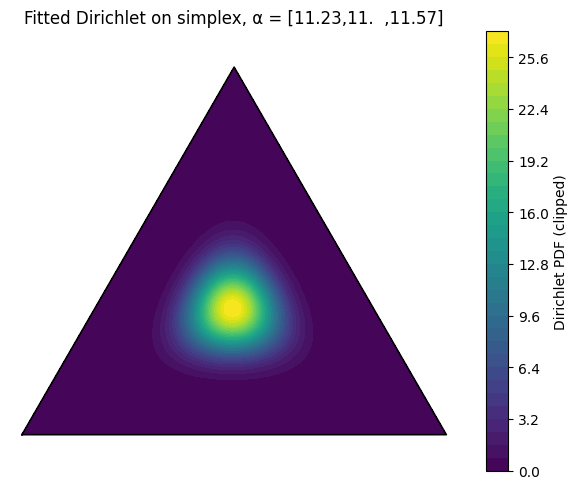

In [106]:
# Fit a Dirichlet to D_train with method-of-moments, then plot the fitted density
m = D_train.mean(axis=0)
v = D_train.var(axis=0) + 1e-8

alpha0_candidates = m * (1 - m) / v - 1
valid = alpha0_candidates[np.isfinite(alpha0_candidates) & (alpha0_candidates > 0)]
alpha0 = np.median(valid) if valid.size > 0 else 10.0
alpha_fit = np.clip(m * alpha0, 1e-3, None)

print("Fitted Dirichlet alpha:", np.round(alpha_fit, 4))

if D_train.shape[1] == 3:
    # Simplex grid (barycentric coordinates)
    n = 180
    bary = np.array(
        [[i / n, j / n, (n - i - j) / n] for i in range(n + 1) for j in range(n + 1 - i)]
    )

    eps = 1e-8
    x = np.clip(bary, eps, 1 - eps)

    log_B = np.sum([lgamma(a) for a in alpha_fit]) - lgamma(np.sum(alpha_fit))
    log_pdf = np.sum((alpha_fit - 1.0) * np.log(x), axis=1) - log_B
    pdf = np.exp(log_pdf)

    # Map simplex to 2D triangle
    xy = np.column_stack([
        bary[:, 1] + 0.5 * bary[:, 2],
        (np.sqrt(3) / 2.0) * bary[:, 2]
    ])

    tri = plt.matplotlib.tri.Triangulation(xy[:, 0], xy[:, 1])
    vmax = np.percentile(pdf, 99.9)

    plt.figure(figsize=(6, 5))
    cntr = plt.tricontourf(tri, np.clip(pdf, 0, vmax), levels=40, cmap="viridis")
    plt.colorbar(cntr, label="Dirichlet PDF (clipped)")
    plt.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], "k-", lw=1.2)
    plt.title("Fitted Dirichlet on simplex, α = " + np.array2string(alpha_fit, precision=2, separator=","))
    plt.axis("equal")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(6, 3))
    plt.bar(np.arange(len(alpha_fit)), alpha_fit)
    plt.xlabel("label index")
    plt.ylabel("alpha")
    plt.title("Fitted Dirichlet parameters")
    plt.tight_layout()
    plt.show()